# Анимация маркировки классической сети

Отдельный сценарий воспроизводит обязательный опыт для трёх философов на
горизонте 30. Каждый кадр соответствует фактически сохранённой маркировке.

In [1]:
using DrWatson
@quickactivate "PetriDiningLab"

ENV["GKSwstype"] = "100"
using CairoMakie
using CSV
using DataFrames
using Random

include(srcdir("DiningPhilosophers.jl"))
using .DiningPhilosophers

## Условия опыта

In [2]:
const PHILOSOPHERS = 3
const HORIZON = 30.0
const FRAME_RATE = 5
const RATES = vcat(fill(2.4, PHILOSOPHERS),
                   fill(0.8, PHILOSOPHERS),
                   fill(1.1, PHILOSOPHERS))

net, initial = build_classical_network(PHILOSOPHERS)
simulation = simulate_stochastic(net, initial, HORIZON;
    rates=RATES, rng=MersenneTwister(123))

mkpath(datadir("dining-animation"))
mkpath(plotsdir())
CSV.write(datadir("dining-animation", "trajectory.csv"),
          simulation.trajectory)
CSV.write(datadir("dining-animation", "events.csv"), simulation.events)

"/workspace/labs/lab05/project/data/dining-animation/events.csv"

## Построение кадров

In [3]:
trajectory = simulation.trajectory
labels = string.(net.place_names)
frame = Observable(1)
values = @lift(Float64[trajectory[$frame, name] for name in net.place_names])
caption = @lift("Классическая сеть, t = " *
                string(round(trajectory.time[$frame]; digits=3)))

figure = Figure(size=(1200, 720), fontsize=16)
axis = Axis(figure[1, 1], title=caption, xlabel="Позиции сети Петри",
            ylabel="Число фишек", xticks=(1:length(labels), labels),
            xticklabelrotation=pi / 4, limits=(nothing, (0, 2.0)))
barplot!(axis, 1:length(labels), values;
         color=repeat([:royalblue3, :darkorange2, :seagreen3, :goldenrod2],
                      inner=PHILOSOPHERS))

gif_path = plotsdir("philosophers_simulation.gif")
record(figure, gif_path, 1:nrow(trajectory); framerate=FRAME_RATE) do index
    frame[] = index
end

"/workspace/labs/lab05/project/plots/philosophers_simulation.gif"

## Контрольные маркировки

1×7 DataFrame
 Row │ philosophers  horizon  fps    frames  events  deadlock  final_time
     │ Int64         Float64  Int64  Int64   Int64   Bool      Float64
─────┼────────────────────────────────────────────────────────────────────
   1 │            3     30.0      5       7       6      true     1.24057
Анимация сохранена: plots/philosophers_simulation.gif


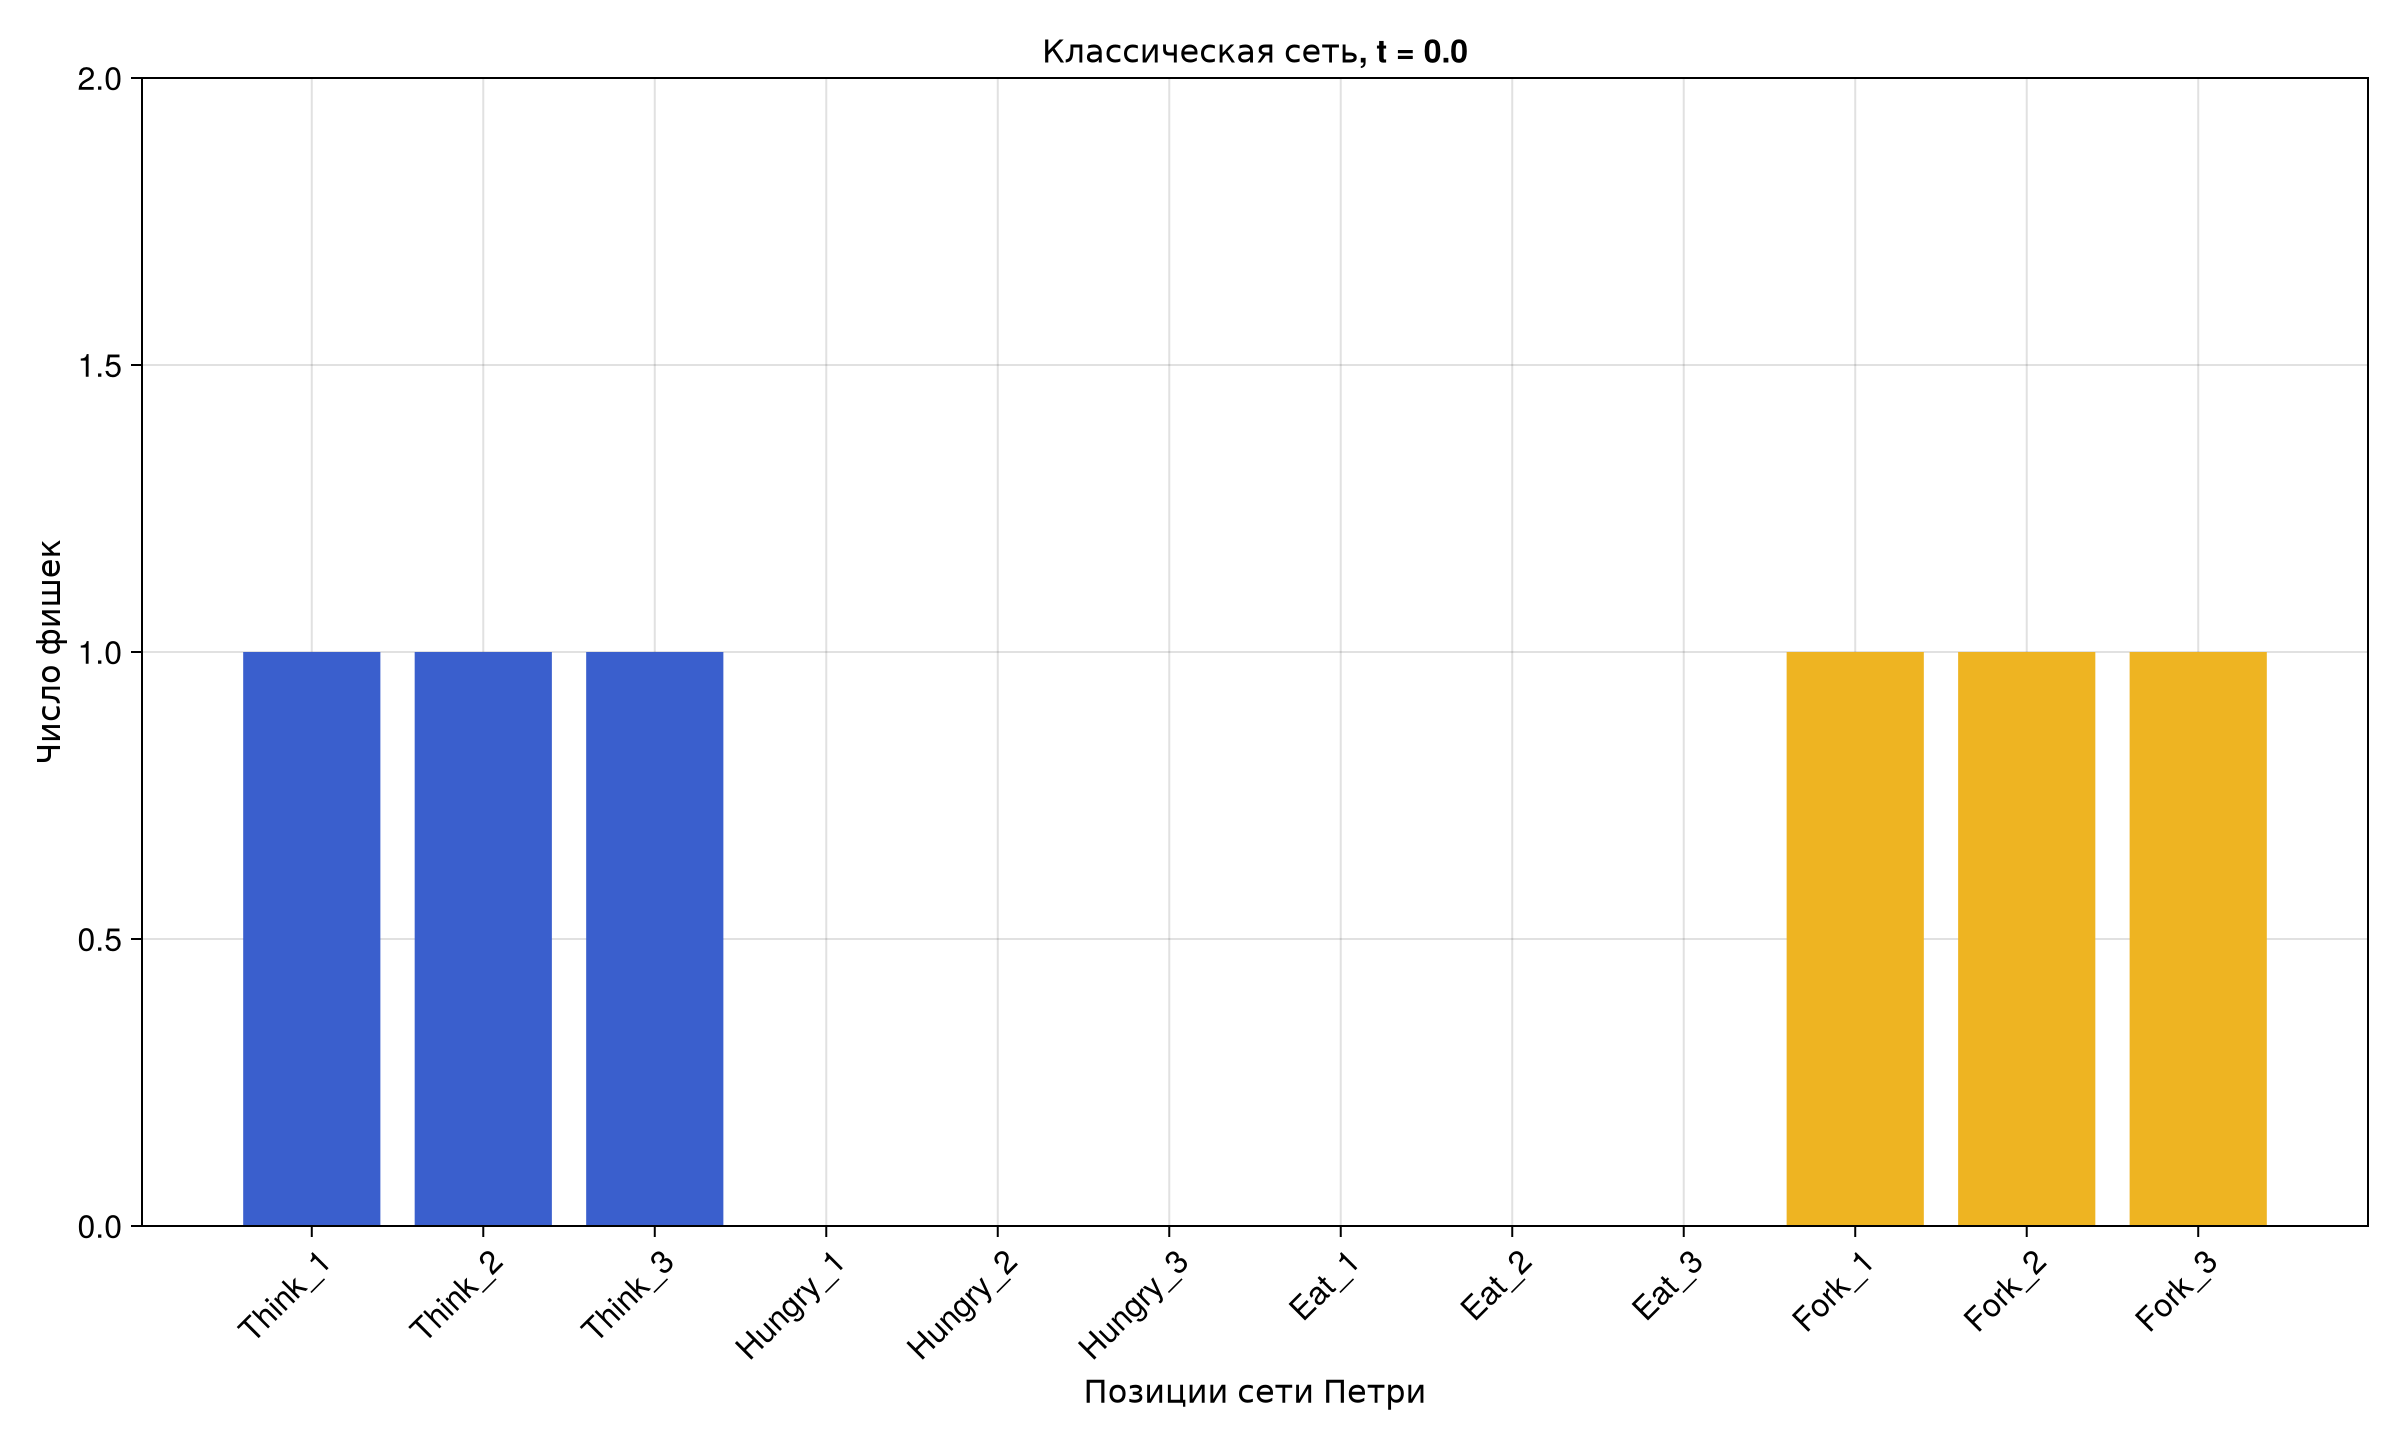

In [4]:
selected = unique(round.(Int,
    range(1, nrow(trajectory); length=min(4, nrow(trajectory)))))
keyframes = Figure(size=(1200, 760), fontsize=15)
for (panel, index) in enumerate(selected)
    row = div(panel - 1, 2) + 1
    column = mod(panel - 1, 2) + 1
    ax = Axis(keyframes[row, column],
              title="t=$(round(trajectory.time[index]; digits=3))",
              xticks=(1:length(labels), labels), xticklabelrotation=pi / 3,
              limits=(nothing, (0, 2.0)))
    barplot!(ax, 1:length(labels),
             Float64[trajectory[index, name] for name in net.place_names];
             color=:royalblue3)
end
save(plotsdir("philosophers_keyframes.png"), keyframes, px_per_unit=1.5)

animation_summary = DataFrame(
    philosophers=[PHILOSOPHERS], horizon=[HORIZON], fps=[FRAME_RATE],
    frames=[nrow(trajectory)], events=[nrow(simulation.events)],
    deadlock=[simulation.deadlock], final_time=[last(trajectory.time)],
)
CSV.write(datadir("dining-animation", "summary.csv"), animation_summary)
show(animation_summary; allrows=true, allcols=true)
println()
println("Анимация сохранена: $(relpath(gif_path, projectdir()))")
keyframes
display(MIME("image/gif"), read(gif_path))